# TermsConditioned: calibrated clause triage and slice audit <br>
## Graduate project, DATA 512: Human Centered Data Science


**Author:** Akshan Krithick  
**Course:** DATA 512 - Human Centered Data Science  
**Assignment:** A7 - Final Project Report  

## Motivation and Problem Statement:
Most people accept Terms and Conditions without reading more than a few lines. Important passages such as “we may change these terms at any time,” “disputes must go to binding arbitration,” or “our liability is limited” are embedded in long, dense paragraphs that few readers have the time or expertise to parse. When these paragraphs are overlooked, the practical impact shows up later as fewer options for recourse, stricter obligations, or surprise limitations. In this report, all experiments are run on LEDGAR contract paragraphs, which I use as a stand-in for Terms-and-Conditions-style legal prose.


This project studies how a simple, transparent assistant could help readers and small teams focus their limited attention on the parts of Terms and Conditions that are most likely to affect them. Rather than trying to “interpret the law,” the system does something narrower and more mechanical: it predicts the clause family for each paragraph using a supervised classifier, and then applies a fixed policy that treats certain families as “attention relevant.” The output is a short “review card” per paragraph that includes the predicted family, a calibrated confidence score, a few phrase flags, and a recommended action: treat as low attention, treat as attention-worthy, or send to a human for review.


The core question is not whether the model can tell what is risky. Instead, I ask: if you use a clause-family classifier as a triage assistant under a conservative decision rule, where does it give false reassurance, and where does it over-flag? I am interested in documenting which clause families are most often under-attended, which writing styles (length, density) correlate with errors, and whether a small set of phrase flags and slice summaries is enough to communicate the assistant’s behavior to non-expert stakeholders. The goal is not to replace legal practice, but to reduce avoidable blind spots for everyday readers by making machine behavior explicit and auditable.

<br>

## Data selected for analysis:
I use the LEDGAR subset of the LexGLUE benchmark, as provided on Hugging Face under the coastalcph/lex_glue repository. <hr>

**Dataset description**
- LEDGAR contains paragraph-level excerpts from real contracts filed with the U.S. Securities and Exchange Commission (SEC) through EDGAR.
- Each paragraph is labeled with a single clause family, such as Arbitration, Governing Laws, Jurisdictions, Remedies, Indemnity, Waivers, Amendments, and many others.
- The dataset provides standard train, validation, and test splits and is large enough to support slice-level analysis by family, length, and simple text features.


The LexGLUE dataset card on Hugging Face documents the license (The dataset card on Hugging Face lists CC-BY-4.0 for the collection, with LEDGAR documentation and standard loading interfaces.) and cites both the LEDGAR paper and the LexGLUE benchmark paper. I follow that card for licensing and citation.

**Link**: https://huggingface.co/datasets/coastalcph/lex_glue
<hr>

**Why this data?**

LEDGAR closely matches the task I care about: deciding “what kind of clause is this paragraph” inside long legal documents. That makes it an appropriate laboratory for studying a triage assistant that surfaces attention relevant families such as arbitration, liability limitations, and waivers. Because LEDGAR is relatively large and spans many contract topics, it also supports the kind of slice analysis I need: I can measure how often the assistant under-attends particular families, and how that behavior varies across length quartiles and phrase flags.
In the report, I treat the LEDGAR paragraphs as a stand-in for Terms and Conditions style text. I do not claim that results generalize to all consumer policies. I report results explicitly “on LEDGAR style contract paragraphs.”

<br>

## Ethical Considerations and Scope:
The LEDGAR data comes from SEC filings that are already public. I follow the dataset license, cite the original sources, and do not attempt to deanonymize or link specific paragraphs back to real parties or cases.

The system I build is a triage assistant, not a legal decision maker:
- It predicts clause families and then applies a mechanically defined policy that tags certain families as "attention relevant."
- It does not estimate actual legal risk or fairness.
- It does not provide legal advice.



All outputs are framed as “review priorities” or “attention suggestions” for humans. I explicitly avoid language that suggests the model can tell whether a clause is fair, enforceable, or acceptable. In particular, computing a calibrated probability over clause families and summing it over a set of attention families is only a proxy for how strongly the classifier thinks this paragraph belongs to those families, not a measure of how risky the clause is in law.

<br>

## Background and Related Work:
There is a substantial literature on legal text classification and on surfacing problematic contract language for non-expert readers.
- **LEDGAR and clause classification.** Tuggener et al. introduce LEDGAR as a large-scale corpus for classifying contract provisions by topic, demonstrating that clause family prediction is feasible and that modern language models perform well on this task [1].
- **LexGLUE benchmark.** Chalkidis et al. aggregate LEDGAR and several other legal datasets into the LexGLUE benchmark, standardizing splits and metrics for legal language understanding tasks [2]. This work motivates my choice to use LEDGAR and to follow the official train/validation/test splits.
- **Unfair clauses and online Terms of Service.** Lippi et al. present CLAUDETTE, a system that detects potentially unfair clauses in online Terms of Service [3]. Their work focuses on unfairness and consumer protection, and uses a different data source. My project is inspired by their framing that certain paragraphs in boilerplate policies deserve extra scrutiny from users, but I focus on clause family recognition and calibrated triage rather than unfairness detection.


These prior efforts motivate two design choices in TermsConditioned. First, clause family classification is a realistic upstream task for a triage assistant, because the families themselves map to topics that legal teams already track. Second, it is not enough to report accuracy or F1: for a human-centered tool, we need to know where the assistant gives false reassurance, and we need artifacts like slice tables and explanations that non-ML stakeholders can interpret.

<br>

## Unknowns and dependencies:
Some clause families are similar (for example, Remedies vs. Indemnity), so misclassifications between closely related families can be hard to interpret; the analysis reports where this happens and avoids over-interpreting small differences. Generalization is also an issue; language varies across companies, so findings are framed as applying to LEDGAR-like text and clearly marked as out-of-scope for other domains. In addition, all results depend on the chosen review-worthy bucket and operating threshold τ*: different buckets or thresholds would shift the balance between missed and extra review cases. The report fixes these choices and treats them as part of the design, not as ground truth about legal risk.

<br>

## Research Questions:<br>


This project treats a clause triage assistant as a tool that skims contract paragraphs and decides which ones deserve extra human attention. The focus is on how such a tool behaves, not on any specific architecture. The main questions are:

1. **Where does a clause triage assistant tend to give false reassurance?**
When a model is used to highlight only a subset of clause topics as “review worthy”, which kinds of clauses and which surface patterns (such as length, density, or key phrases) most often slip through as low-attention even though they belong to that review-worthy group?

2. **What tradeoffs does the assistant make between reassurance and caution, and how easy are those tradeoffs to explain?**
When the assistant is tuned to keep most paragraphs while limiting missed review cases, how large is the remaining gap between under-flagging and over-flagging, and can simple slice summaries and phrase-based highlights make this behavior understandable to non-expert stakeholders?

The answers to these questions are meant to guide how such a tool should be used in practice and how its limitations should be documented.


<br>

## Methodology:
1. **Overall design**

    The system has three main components:

- A supervised classifier that predicts the clause family for each paragraph.
- A calibration step that makes the classifier’s confidence scores better aligned with empirical correctness.
- A simple decision policy that maps calibrated scores and clause families to one of three actions: “treat as low attention,” “flag as attention relevant,” or “abstain and send to human review.”


  On top of this, I add a human-centered analysis layer that slices the validation data by clause family, length, a readability proxy, and simple phrase flags, and then measures where the assistant tends to produce false greens (missed attention).

<br>

2. **Data preprocessing and slice construction**

    I retain the text and labels fields as provided in the LEDGAR subset of LexGLUE, and I use the official train, validation, and test splits.

    For slice analysis, I create additional features, but these are not used as labels or as features in the classifier:

- **Length buckets.** I compute a rough token count for each paragraph by splitting on whitespace and bin paragraphs into quartiles (n_tok_Q1 to n_tok_Q4). I do the same for character length (n_char_Q1 to n_char_Q4).

- **Readability proxy.** I compute characters per token as a coarse proxy for density and bin it into quartiles as well.
- **Phrase flags.** I define a small set of regular expression flags that capture stock phrases often associated with important passages, such as “binding arbitration,” “limitation of liability,” “governing law,” “exclusive jurisdiction,” “sole discretion,” “to the maximum extent permitted by law,” and “including but not limited to.” Each flag is a binary indicator for whether the phrase appears in the paragraph.
- **Attention bucket.** A small set of clause families is treated as “review worthy” for this study, including Waivers, Waiver Of Jury Trials, Arbitration, Remedies, Indemnity, Indemnifications, Governing Laws, Jurisdictions, Submission To Jurisdiction, Consent To Jurisdiction, Amendments, and Modifications. All results about missed or over-applied attention are always relative to this declared bucket: the assistant is evaluated on how often it under-flags or over-flags clauses from this list, not on any claim about legal risk in general.


    These slice features allow me to ask questions like: “Among paragraphs that are truly in the attention bucket and fall in the longest length quartile, how often does the assistant fail to flag them?”

<br>

3. **Classifier and calibration**

    For the classifier, I fine-tune a RoBERTa large encoder with a sequence classification head on the LEDGAR training split:
- I use the RoBERTa large tokenizer with a maximum length of 384 tokens.
- I adapt the model using LoRA (Low Rank Adapters) so that only a small number of additional parameters are trained on top of the base model.
- I train using a class-weighted, label-smoothed cross-entropy loss to reduce the impact of label imbalance across families and to improve calibration.


    After training, I run the model on the validation split and collect logits and labels. I then apply temperature scaling, fitting a single scalar temperature T* on the validation set to minimize expected calibration error. The calibrated probabilities are obtained by dividing logits by T* before applying softmax. I verify that calibration improves by reporting ECE before and after scaling.
<br>

4. **Decision policy and analytical metrics**

    The decision policy is a simple rule that either sends a paragraph to review, flags it as attention-relevant, or leaves it as low-attention based on the model’s score and whether its predicted family is in the review-worthy bucket.

    I define a decision policy that uses the calibrated maximum probability and the clause family to select an action:
- If the maximum calibrated probability is below a threshold τ, the assistant abstains and returns “needs review.”
- Otherwise, if the predicted family is in the attention bucket, the assistant returns “attention recommended.”
- Otherwise, it returns “low attention.”


    I choose τ on the validation set by sweeping a grid of thresholds and selecting the operating point that approximately satisfies two conditions:
  1. The rate of under-attention events (paragraphs truly in the attention bucket that are kept and treated as low attention) among kept attention bucket paragraphs is bounded by a pre-specified cap.
  2. The overall keep rate is not driven too low by overuse of abstention.

  <hr>

    Once τ is fixed, I compute:
- Per-family slice level summary metrics.
- False green (under-attention) rates within each slice defined by clause family, length, readability proxy, and phrase flags, plus global false red and abstain rates at the chosen operating point.
- A simple harm score per slice, defined as the number of attention bucket paragraphs that are kept multiplied by the under-attention rate within that slice. This score is a way to rank slices by how many problematic cases they plausibly contain.


  These metrics answer the research questions about where the assistant misbehaves and how that behavior clusters.

  All calibration, threshold selection, and slice analysis are performed on the validation split. The test split is left unused here, since the goal is to characterise behaviour under a fixed operating point rather than to report a single held-out score.

  <br>
5. **Outputs and “review cards”**

    Finally, I define a lightweight interface that produces review cards at the paragraph and document level:
- For a single paragraph, the card reports the predicted clause family, calibrated confidence, whether the family is in the attention bucket, any phrase flags that fired, a recommended action based on the decision rule, and a short text span that serves as a rationale (either the first matched flag or a short excerpt).
- For a longer Terms and Conditions style document, I split on blank lines into paragraphs, apply the triage function to each one, and then rank paragraphs by a simple severity score (attention recommended above needs review above low attention). The top-ranked paragraphs form a review queue for human readers.


    These outputs are designed to be inspected qualitatively in the notebook and to serve as examples of how the system would behave in a realistic reading flow. They also provide concrete artifacts to connect the slice-level error analysis back to individual paragraphs.

These methods are appropriate for a human-centered triage setting because they produce calibrated, interpretable scores and slice-level error summaries rather than only a single accuracy figure. Calibration makes the assistant's confidence usable as a risk-style signal, and the fixed decision policy plus slice tables make it possible to see where the assistant gives false reassurance, which is more relevant to readers than raw classification accuracy.

<br>

## IMPLEMENTATION

Note: In order to reproduce this notebook and run all cells successfully, click runtime -> select runtime type -> select T4 ( or higher GPU )

Deliverables you will have by the end of this notebook:

• Trained a supervised clause classifier on a contract clause dataset and converted its outputs into a calibrated “review worthiness” score using temperature scaling, achieving 86.9 percent validation accuracy, 0.79 macro F1, and reducing expected calibration error from 0.035 to 0.008.

• Designed a simple triage rule over the calibrated score that automatically green-lit about 99.5 percent of clauses while capping “review worthy but treated as low attention” errors (false greens) at roughly 4 to 5 percent, making the tradeoff between coverage and caution explicit for reviewers.

• Built slice audits over clause families, length buckets, and regex phrase flags, ranking slices by a harm score that combines volume and false-green rate and surfacing brittle regions such as Waivers, Remedies, long clauses, and “sole discretion” language.

# SETUP

Install and pin all core dependencies used in this notebook: PyTorch and Transformers for modeling, PEFT and bitsandbytes for efficient fine-tuning, Evaluate and scikit-learn for metrics, and pandas/pyarrow/datasets for data handling. Also the cell resets the preinstalled Torch stack

In [ ]:
!pip uninstall -y torch torchvision torchaudio

!pip install -U \
  "torch==2.4.0"\
  "transformers==4.43.3" \
  "accelerate==0.29.3" \
  "peft==0.13.0" \
  "bitsandbytes" \
  "evaluate==0.4.2"\
  "scikit-learn==1.5.2"\
  "pandas==2.2.2"\
  "pyarrow"\
  "datasets==3.0.0"\
  -q


Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Import the main libraries, check that the key ML packages are available, and set up reproducibility (random seeds, device, and default dtype) for the rest of the notebook.

In [ ]:
import importlib, sys, random, math, os, json, shutil, re
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import bitsandbytes as bnb
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

from peft import LoraConfig, get_peft_model

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("bnb:", bnb.__version__)
for m in ["evaluate","datasets","transformers","peft","accelerate","bitsandbytes"]:
    try:
        importlib.import_module(m)
        print(m, "OK")
    except Exception as e:
        print(m, "ERR:", e)

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(123)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

Torch: 2.4.0+cu121 | CUDA: True
GPU: Tesla T4
bnb: 0.48.2
evaluate OK
datasets OK
transformers OK
peft OK
accelerate OK
bitsandbytes OK


Authenticate with Hugging Face so this notebook can download or save models that require a logged-in user.

Run the cell below and paste a token with "write" access from https://huggingface.co/settings/tokens into the prompt that `login()` opens. Do **not** paste the token directly into the notebook.

In [ ]:
from huggingface_hub import login
login()

Load the LEDGAR contract-clause dataset and set up the basic features the rest of the notebook will use.

This cell:
- Loads the LEDGAR split from `coastalcph/lex_glue` and pulls out the clause texts and label names.
- Defines a subset of clause families as "high-impact" (`RISKY`) that we care most about when we analyze errors.
- Computes simple length features on the validation set (token count, character count, and chars-per-token) and buckets them into quartiles; these will be used later for length/readability slice analysis.
- Builds a `flag_df` of binary regex indicators for specific legal phrases (e.g., "binding arbitration", "sole discretion", "governing law"), which will also be used later as slice dimensions when we audit the model.


Load the LEDGAR dataset, mark a subset of clause families as “risky”, and precompute validation slices (length quartiles and regex-based flags for risky motifs). These slices will be used later to audit the classifier's behavior and to compute per-slice harm scores.


In [ ]:
# 1. Load LEDGAR
ds = load_dataset("coastalcph/lex_glue", "ledgar")
label_names = ds["train"].features["label"].names
id2name = {i: n for i, n in enumerate(label_names)}
name2id = {n: i for i, n in id2name.items()}
num_labels = len(label_names)

# risky families: missing these is a false green-light
RISKY = {
    "Arbitration","Waiver Of Jury Trials","Waivers",
    "Jurisdictions","Submission To Jurisdiction","Consent To Jurisdiction","Governing Laws",
    "Modifications","Amendments",
    "Limitation Of Liability","Remedies","Indemnity","Indemnifications"
} & set(label_names)

print("Num labels:", num_labels)
print("Risky families:", sorted(RISKY))

train_txt = ds["train"]["text"]
val_txt   = ds["validation"]["text"]
test_txt  = ds["test"]["text"]

# 1.1 Length buckets on validation
def count_tokens_rough(texts):
    return np.array([len(t.split()) for t in texts])

VAL_TOK  = count_tokens_rough(val_txt)
VAL_CHAR = np.array([len(t) for t in val_txt])
VAL_CPT  = VAL_CHAR / np.maximum(VAL_TOK, 1)

def quartile_bucket(x, prefix):
    q1, q2, q3 = np.quantile(x, [0.25, 0.5, 0.75])
    def b(v):
        if v <= q1: return f"{prefix}_Q1"
        if v <= q2: return f"{prefix}_Q2"
        if v <= q3: return f"{prefix}_Q3"
        return f"{prefix}_Q4"
    return np.array([b(v) for v in x])

VAL_NTOK_BUCKET = quartile_bucket(VAL_TOK,  "n_tok")
VAL_NCHR_BUCKET = quartile_bucket(VAL_CHAR, "n_char")
VAL_CPT_BUCKET  = quartile_bucket(VAL_CPT,  "chars_per_tok")

assert len(val_txt) == len(VAL_NTOK_BUCKET) == len(VAL_NCHR_BUCKET) == len(VAL_CPT_BUCKET)

# 1.2 Regex flags for risky motifs (on validation only)
FLAGS = {
    "flag_binding_arbitration": r"\bbinding arbitration\b|\barbitration\b",
    "flag_limitation_liability": r"\blimitation of liability\b|\bdisclaim(?:er|s)\b",
    "flag_governing_law": r"\bgoverning law\b|\bapplicable law\b",
    "flag_venue_jurisdiction": r"\bvenue\b|\bjurisdiction\b|\bexclusive jurisdiction\b",
    "flag_sole_discretion": r"\bsole discretion\b",
    "flag_max_extent_law": r"\bmaximum extent permitted by law\b",
    "flag_including_not_limited": r"\bincluding(?:,|\s) but not limited to\b|\bincluding without limitation\b",
}

flag_df = pd.DataFrame({
    k: pd.Series(val_txt).str.lower().str.contains(rx, regex=True, na=False).astype(int)
    for k, rx in FLAGS.items()
})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ledgar/train-00000-of-00001.parquet:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

ledgar/test-00000-of-00001.parquet:   0%|          | 0.00/3.31M [00:00<?, ?B/s]

ledgar/validation-00000-of-00001.parquet:   0%|          | 0.00/3.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Num labels: 100
Risky families: ['Amendments', 'Arbitration', 'Consent To Jurisdiction', 'Governing Laws', 'Indemnifications', 'Indemnity', 'Jurisdictions', 'Modifications', 'Remedies', 'Submission To Jurisdiction', 'Waiver Of Jury Trials', 'Waivers']


In this notebook I mark a fixed subset of clause families (for example Waivers, Indemnity, Arbitration, Governing Laws) as a “risk bucket”. This is simply a set of families I want to monitor more closely in the analysis. Whenever I say “risky vs safe” later, it just means “in this bucket vs not in this bucket”.

# CLASSIFIER

Train a clause-family classifier (classifier) from scratch (optional)

This cell fine-tunes a RoBERTa-large encoder on the LEDGAR clause labels using:

- A custom `WeightedTrainer` that applies class weights (to handle imbalanced families) and label smoothing.
- LoRA adapters on the encoder and classifier head so only a small number of parameters are updated.
- Standard training hyperparameters (5 epochs, cosine schedule, AdamW with 8-bit optimizer).

The result is a multi-class classifier that predicts a clause family for each paragraph; later cells turn these logits into a calibrated “high-impact” score and slice audits.

**Note: *Training RoBERTa-large end-to-end is expensive. For the main analysis below, the notebook loads a pre-trained classifier from Hugging Face instead, so this cell can be skipped unless you want to try out custom hyperparameters.***




In [ ]:
# 2A. Classifier training (optional, heavy)

BASE_ENC = "roberta-large"
MAX_LEN = 384

tok = AutoTokenizer.from_pretrained(BASE_ENC, use_fast=True)

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding=False, max_length=MAX_LEN)

tok_ds = ds.map(tokenize, batched=True)
tok_ds = tok_ds.rename_column("label", "labels")
tok_ds = tok_ds.remove_columns(["text"])

collator = DataCollatorWithPadding(tok, pad_to_multiple_of=8, return_tensors="pt")

from collections import Counter

counts = Counter(tok_ds["train"]["labels"])
counts_arr = np.array([counts[i] for i in range(num_labels)], dtype=float)
median_c = np.median(counts_arr)
class_weights = median_c / np.maximum(counts_arr, 1.0)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits
        cw = torch.tensor(class_weights, device=logits.device, dtype=logits.dtype)

        eps = 0.1  # label smoothing
        log_probs = torch.log_softmax(logits, dim=-1)
        nll = -log_probs.gather(dim=-1, index=labels.unsqueeze(1)).squeeze(1)
        smooth = -log_probs.mean(dim=-1)
        loss_vec = (1 - eps) * nll + eps * smooth
        loss = (loss_vec * cw[labels]).mean()
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_ENC,
    num_labels=num_labels,
    torch_dtype=DTYPE,
)
model.config.use_cache = False

lcfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
    target_modules=["query","key","value","intermediate.dense","output.dense"],
    modules_to_save=["classifier"],
)
model = get_peft_model(model, lcfg)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable/1e6:.2f}M / {total/1e6:.2f}M")

import evaluate
acc_metric = evaluate.load("accuracy")
f1m_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1m_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

OUT_DIR_CLS = "/content/termsconditioned_encoder_lora"

args = TrainingArguments(
    output_dir=OUT_DIR_CLS,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=False,
    metric_for_best_model=None,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    num_train_epochs=5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    weight_decay=0.1,
    max_grad_norm=1.0,
    fp16=False,
    bf16=torch.cuda.is_available(),
    logging_steps=100,
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
    optim="adamw_bnb_8bit",
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tok,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["validation"],
)

train_out = trainer.train()
print(train_out)

eval_out = trainer.evaluate(tok_ds["validation"])
print("Final validation metrics:", eval_out)

# save locally so you can push to HF manually
model.save_pretrained(OUT_DIR_CLS, safe_serialization=True)
tok.save_pretrained(OUT_DIR_CLS)

meta = {
    "base_model": BASE_ENC,
    "num_labels": num_labels,
    "label_names": label_names,
    "risky_families": sorted(list(RISKY)),
    "max_length": MAX_LEN,
}
with open(os.path.join(OUT_DIR_CLS, "config.json"), "w") as f:
    json.dump(meta, f, indent=2)


Load the pre-trained classifier from Hugging Face (default path)

Instead of re-training RoBERTa-large, this cell loads the published TermsConditioned classifier checkpoint from the Hugging Face Hub, attaches its LoRA adapters, moves it to the available device (CPU or GPU), and switches it to evaluation mode. All later analysis (calibration, slices, and risk-style scores) uses this loaded classifier.

**Link to termsConditioned LoRA adapters:** https://huggingface.co/akshan-main/termsconditioned-roberta-large-ledgar-lora

In [ ]:
# 2B. Load classifier from HF (default)
from peft import PeftModel

classifier_lora = "akshan-main/termsconditioned-roberta-large-ledgar-lora"  # adjust to exact name

BASE_ENC = "roberta-large"
MAX_LEN = 384

tokenizer = AutoTokenizer.from_pretrained(BASE_ENC)
model = AutoModelForSequenceClassification.from_pretrained(
    classifier_lora,
    num_labels=100,
    torch_dtype=DTYPE,
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model = PeftModel.from_pretrained(model, classifier_lora)
model.eval()

print("Loaded model from HF:", classifier_lora)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

adapter_config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adapter_model.safetensors:   0%|          | 0.00/33.0M [00:00<?, ?B/s]

Loaded model from HF: akshan-main/termsconditioned-roberta-large-ledgar-lora


  <br>

The next cell summarizes the global tradeoffs between false reassurance (false greens), extra caution (false reds), and abstentions at the chosen operating point, addressing the second Research Question about overall behavior.

# CALIBRATION AND POLICY

Compute calibrated classifier scores and pick a triage threshold

Run the trained clause classifier on the LEDGAR validation set, cache its raw logits and labels, and turn them into probabilities. Then:

- Measure baseline validation accuracy and macro F1.
- Sweep a grid of temperature values and pick the T* that minimises Expected Calibration Error (ECE), so that a score like 0.7 really means “about 70 percent of similar predictions are correct”.
- Use the calibrated probabilities to sweep over confidence thresholds τ. For each τ compute:
  - `kept_rate` and `abstain_rate`
  - false green rate among risky clauses we keep (treating risky as safe)
  - false red rate among safe clauses we keep (treating safe as risky)
  - recall on risky clauses that are kept
- Select a single operating threshold τ* that keeps most clauses automated while capping the false green rate on risky clauses.

This cell produces:
- `SUMMARY` with calibration statistics  
- `OPERATING_POINT` with the chosen τ*  
- `policy_sweep.csv` with the full threshold sweep.
<hr>

At this point I have a trained clause classifier that outputs a probability for every clause family. I turn that into a single risk score in [0, 1] by summing the probabilities over the risk bucket defined earlier. So:

- "Risky" means "predicted family is in that bucket",

- "Risk score" means "how much probability mass the classifier puts on that bucket".

This is a technical proxy over clause families, not a general legal notion of risk.

In [ ]:
# 3. Compute validation logits and calibration

# Tokenized validation, reusing tok_ds if you have it
# If you did not run 2A in this notebook, you need to rebuild tok_ds here:
EXPORT_DIR = "/content/termsconditioned_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

BASE_ENC = "roberta-large"
MAX_LEN = 384

tok = AutoTokenizer.from_pretrained(BASE_ENC, use_fast=True)
def tokenize(batch):
    return tok(batch["text"], truncation=True, padding=False, max_length=MAX_LEN)

tok_ds = ds.map(tokenize, batched=True)
tok_ds = tok_ds.rename_column("label", "labels")
tok_ds = tok_ds.remove_columns(["text"])

collator = DataCollatorWithPadding(tok, pad_to_multiple_of=8, return_tensors="pt")

val_loader = DataLoader(
    tok_ds["validation"],
    batch_size=64,
    shuffle=False,
    collate_fn=collator,
)

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        labels = batch["labels"]
        inputs = {k: v.to(model.device) for k, v in batch.items() if k != "labels"}
        outputs = model(**inputs)
        # cast logits to float32 before moving to numpy later
        all_logits.append(outputs.logits.detach().float().cpu())
        all_labels.append(labels.cpu())

logits_val = torch.cat(all_logits, dim=0).numpy()  # now float32, numpy is happy
y_true = torch.cat(all_labels, dim=0).numpy()


print("Val logits shape:", logits_val.shape)

from sklearn.metrics import accuracy_score, f1_score

y_pred = logits_val.argmax(axis=1)
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print("Validation accuracy:", acc)
print("Validation macro F1:", macro_f1)

def softmax_np(x):
    x = x - x.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)

def ece(probs, y, n_bins=15):
    p = probs.max(1)
    c = (probs.argmax(1) == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    err = 0.0
    for i in range(n_bins):
        m = (p >= edges[i]) & (p < edges[i+1])
        if m.sum() == 0:
            continue
        err += abs(c[m].mean() - p[m].mean()) * m.mean()
    return float(err)

T_grid = np.round(
    np.concatenate([np.linspace(0.5, 0.95, 10), np.linspace(1.0, 3.0, 21)]),
    2
)

best_T, best_e = None, 1e9
for T in T_grid:
    P = softmax_np(logits_val / T)
    e = ece(P, y_true)
    if e < best_e:
        best_e, best_T = e, float(T)

rawP = softmax_np(logits_val)
calP = softmax_np(logits_val / best_T)

SUMMARY = {
    "val_acc_raw": float((rawP.argmax(1) == y_true).mean()),
    "val_acc_cal": float((calP.argmax(1) == y_true).mean()),
    "ECE_raw": float(ece(rawP, y_true)),
    "ECE_cal": float(ece(calP, y_true)),
    "best_T": best_T,
    "n_val": int(len(y_true)),
    "mode": "Encoder+LoRA",
}

print("Calibration summary:", SUMMARY)

from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

RISKY_IDS = {i for i, name in id2name.items() if name in RISKY}

def sweep_policy(prob, y_true, tau_grid, risky_ids):
    y_true = np.asarray(y_true)
    conf = prob.max(axis=1)
    y_pred = prob.argmax(axis=1)

    true_risk = np.isin(y_true, list(risky_ids))
    pred_risk = np.isin(y_pred, list(risky_ids))

    rows = []
    for tau in tau_grid:
        keep = conf >= tau

        kept_rate = float(keep.mean())
        abstain_rate = 1.0 - kept_rate

        # among risky clauses that we keep, how often do we miss them (false green)
        mask_risky_kept = true_risk & keep
        n_risky_kept = mask_risky_kept.sum()
        denom_risky = max(n_risky_kept, 1)

        false_green = ((true_risk & keep) & (~pred_risk)).sum() / denom_risky
        risky_recall = ((true_risk & keep) & pred_risk).sum() / denom_risky

        # among safe clauses we keep, how often do we overflag them (false red)
        mask_safe_kept = (~true_risk) & keep
        n_safe_kept = mask_safe_kept.sum()
        denom_safe = max(n_safe_kept, 1)

        false_red = (((~true_risk) & keep) & pred_risk).sum() / denom_safe

        rows.append({
            "tau": float(tau),
            "kept_rate": kept_rate,
            "abstain_rate": abstain_rate,
            "false_green_rate": float(false_green),
            "false_red_rate": float(false_red),
            "risky_recall_kept": float(risky_recall),
            "n_risky_kept": int(n_risky_kept),
            "n_safe_kept": int(n_safe_kept),
        })

    return pd.DataFrame(rows)

tau_grid = np.linspace(0.20, 0.99, 80)
policy_sweep = sweep_policy(calP, y_true, tau_grid, RISKY_IDS)

CAP, MIN_KEEP = 0.05, 0.25

ok = policy_sweep.query("false_green_rate <= @CAP and kept_rate >= @MIN_KEEP")
if len(ok):
    pick = ok.sort_values(
        ["abstain_rate", "risky_recall_kept", "tau"],
        ascending=[True, False, True],
    ).iloc[0]
else:
    pick = policy_sweep.sort_values(
        ["false_green_rate", "abstain_rate", "tau"],
        ascending=[True, False, True],
    ).iloc[0]

tau_star = float(pick["tau"])

OPERATING_POINT = {
    "tau_star": tau_star,
    "cap": CAP,
    "kept_rate_at_tau": float(pick["kept_rate"]),
    "abstain_rate_at_tau": float(pick["abstain_rate"]),
    "false_green_rate_at_tau": float(pick["false_green_rate"]),
    "false_red_rate_at_tau": float(pick["false_red_rate"]),
    "risky_recall_kept_at_tau": float(pick["risky_recall_kept"]),
}

print("Operating point:", OPERATING_POINT)

# save updated sweep with both types of errors
policy_sweep.to_csv(os.path.join(EXPORT_DIR, "policy_sweep.csv"), index=False)

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Val logits shape: (10000, 100)
Validation accuracy: 0.8692
Validation macro F1: 0.7912242143018642
Calibration summary: {'val_acc_raw': 0.8692, 'val_acc_cal': 0.8692, 'ECE_raw': 0.03518115075975656, 'ECE_cal': 0.00854875868819656, 'best_T': 1.2, 'n_val': 10000, 'mode': 'Encoder+LoRA'}
Operating point: {'tau_star': 0.2, 'cap': 0.05, 'kept_rate_at_tau': 0.9947, 'abstain_rate_at_tau': 0.005299999999999971, 'false_green_rate_at_tau': 0.04392106938255888, 'false_red_rate_at_tau': 0.019102196752626553, 'risky_recall_kept_at_tau': 0.9560789306174411}


### Calibration and policy summary

On the LEDGAR validation split, the classifier reaches 0.8692 accuracy and 0.7912 macro F1. The raw probability scores are slightly overconfident (ECE ≈ 0.0352). After temperature scaling with T* = 1.20, ECE drops to ≈ 0.0085, so the scores are well calibrated and can be interpreted as probabilities rather than arbitrary logits.

From the τ sweep, the chosen operating point is τ* = 0.20 under a policy cap on false green lights for attention-bucket clauses. At this τ*:

- kept_rate ≈ 0.9947  
- abstain_rate ≈ 0.0053  
- false_green_rate on risky clauses that are kept ≈ 0.0439  
- false_red_rate on safe clauses that are kept ≈ 0.0191  
- risky_recall_kept ≈ 0.9561  

All later slice audits use this calibrated classifier and this fixed operating point.


# CALIBRATED RISK CLASSIFIER

Evaluate the classifier as a risky vs safe detector

Collapse the multi-class family labels into a binary label (`risky` vs `safe`) and define a scalar risk score for each clause by summing the calibrated probabilities over the risky families.

Using these calibrated risk scores:

- compute ROC and precision-recall curves for detecting risky clauses
- report ROC AUC and average precision as summary numbers
- save the ROC and PR curves to CSV so they can be plotted or inspected later


In [ ]:
# binary labels: 1 if true family is risky, else 0
y_true_risk = np.isin(y_true, list(RISKY_IDS)).astype(int)

# risk score before and after temperature calibration
risk_score_raw = rawP[:, list(RISKY_IDS)].sum(axis=1)
risk_score_cal = calP[:, list(RISKY_IDS)].sum(axis=1)

# ROC and PR for the calibrated risk head
fpr, tpr, roc_th = roc_curve(y_true_risk, risk_score_cal)
prec, rec, pr_th = precision_recall_curve(y_true_risk, risk_score_cal)

roc_auc = roc_auc_score(y_true_risk, risk_score_cal)
ap = average_precision_score(y_true_risk, risk_score_cal)

print(f"Risk ROC AUC (calibrated): {roc_auc:.3f}")
print(f"Risk average precision (calibrated): {ap:.3f}")

# dump curves so you can plot or use in paper later
roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": np.concatenate([roc_th, [np.nan]])[: len(fpr)],
})
pr_df = pd.DataFrame({
    "recall": rec,
    "precision": prec,
})

roc_df.to_csv(os.path.join(EXPORT_DIR, "risk_roc_curve.csv"), index=False)
pr_df.to_csv(os.path.join(EXPORT_DIR, "risk_pr_curve.csv"), index=False)


Risk ROC AUC (calibrated): 0.995
Risk average precision (calibrated): 0.972


**Binary risk detection summary**

Using the calibrated classifier scores as a single “risk indicator”, the model separates risky vs safe families very well on validation:

- Risk ROC AUC ≈ 0.995  
- Risk average precision ≈ 0.972  

This supports using the classifier's calibrated risk score as a meaningful signal when auditing slices and exploring triage rules.
<hr>


**Visualise binary risk detection performance**

Using the previously computed `fpr`, `tpr`, `rec`, `prec`, `roc_auc`, and `ap`, plot:

- the ROC curve (false positive rate vs true positive rate) for detecting risky clauses
- the precision–recall curve for the same task

These plots give a visual sense of how well the calibrated risk score separates risky vs safe clauses across thresholds.


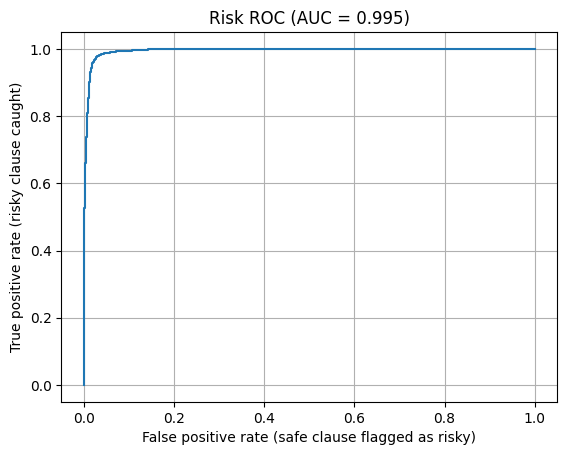

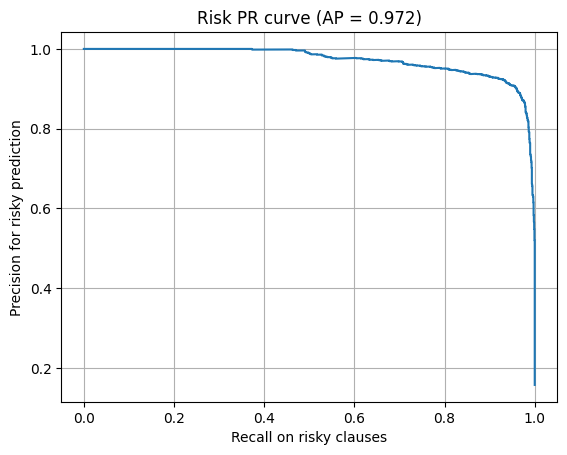

In [ ]:
# ROC curve
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.set_xlabel("False positive rate (safe clause flagged as risky)")
ax.set_ylabel("True positive rate (risky clause caught)")
ax.set_title(f"Risk ROC (AUC = {roc_auc:.3f})")
ax.grid(True)

fig.savefig(os.path.join(EXPORT_DIR, "risk_roc_curve.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# PR curve
fig, ax = plt.subplots()
ax.plot(rec, prec)
ax.set_xlabel("Recall on risky clauses")
ax.set_ylabel("Precision for risky prediction")
ax.set_title(f"Risk PR curve (AP = {ap:.3f})")
ax.grid(True)

fig.savefig(os.path.join(EXPORT_DIR, "risk_pr_curve.png"),
            dpi=200, bbox_inches="tight")
plt.show()

**ROC / PR plots**

Both curves are very strong and consistent with the scalar metrics (ROC AUC ≈ 0.995, AP ≈ 0.97). The classifier's calibrated risk score provides a clean trade-off between catching risky clauses and avoiding over-flagging safe ones, which is important for the later slice audits and triage rule.
<hr>

**Reliability diagrams for confidence and risk head**

Build two calibration curves on the validation set:

- Top1 confidence: bucket clauses by the calibrated max class probability and, for each bin, compare average predicted confidence to the actual accuracy. This checks whether “I am 80% confident” really means “about 80% of these are correct”.
- Risk head: bucket clauses by the calibrated risk score (sum of risky-family probabilities) and, for each bin, compare average predicted risk to the actual fraction of truly risky clauses.

Save both curves to CSV for later inspection and plot reliability diagrams so it is easy to see how close the model is to the ideal diagonal (perfect calibration).


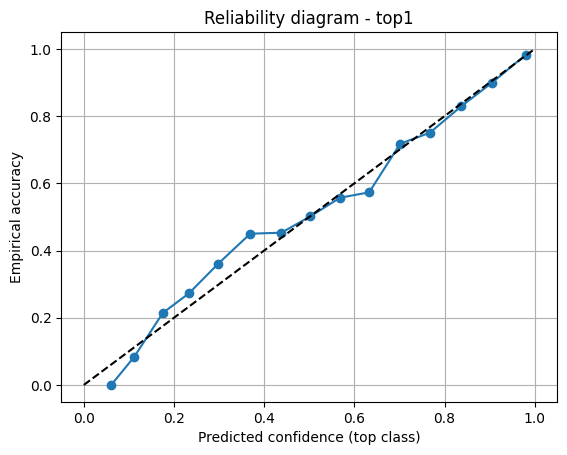

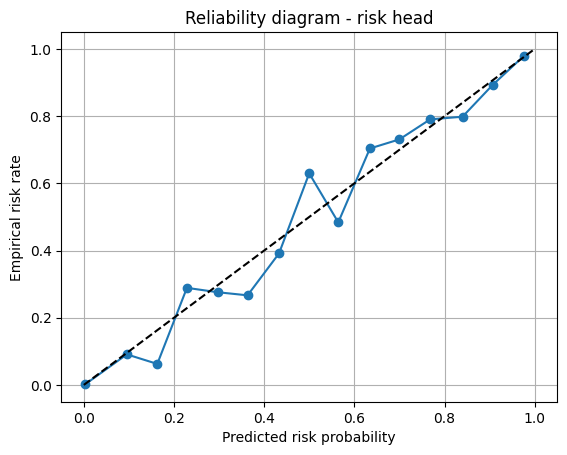

In [ ]:
from sklearn.calibration import calibration_curve

# 3.1 Top class calibration (multi class reduced to top1)
top_conf = calP.max(axis=1)
top_correct = (calP.argmax(axis=1) == y_true).astype(int)

# we use sklearn.calibration on a binary target, but the "prob" is just confidence
prob_true_top, prob_pred_top = calibration_curve(
    top_correct,
    top_conf,
    n_bins=15,
    strategy="uniform",
)

calib_top_df = pd.DataFrame({
    "bin_pred_conf": prob_pred_top,
    "bin_true_acc": prob_true_top,
})
calib_top_df.to_csv(os.path.join(EXPORT_DIR, "calibration_topclass.csv"), index=False)

# 3.2 Risk head calibration
prob_true_risk, prob_pred_risk = calibration_curve(
    y_true_risk,
    risk_score_cal,
    n_bins=15,
    strategy="uniform",
)

calib_risk_df = pd.DataFrame({
    "bin_pred_risk": prob_pred_risk,
    "bin_true_risk_rate": prob_true_risk,
})
calib_risk_df.to_csv(os.path.join(EXPORT_DIR, "calibration_riskhead.csv"), index=False)


# 4. Reliability diagram - top1
fig, ax = plt.subplots()
ax.plot(prob_pred_top, prob_true_top, marker="o")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Predicted confidence (top class)")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Reliability diagram - top1")
ax.grid(True)

fig.savefig(os.path.join(EXPORT_DIR, "reliability_top1.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# 5. Reliability diagram - risk head
fig, ax = plt.subplots()
ax.plot(prob_pred_risk, prob_true_risk, marker="o")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Predicted risk probability")
ax.set_ylabel("Empirical risk rate")
ax.set_title("Reliability diagram - risk head")
ax.grid(True)

fig.savefig(os.path.join(EXPORT_DIR, "reliability_risk_head.png"),
            dpi=200, bbox_inches="tight")
plt.show()

**Reliability of the classifier scores**

This cell checks how well the calibrated classifier probabilities line up with reality and saves the binned calibration data for later use.

* First, it builds a reliability diagram for the top class confidence: the x axis is the model's predicted confidence (for example 0.7), and the y axis is the fraction of those predictions that are actually correct.
* Second, it builds a reliability diagram for the risk probability: the x axis is the summed probability on the “risky” families, and the y axis is the fraction of clauses in that bin whose true family is in the risky set.
* In both plots, the points lie close to the diagonal reference line. That means a predicted score like 0.7 corresponds to roughly 70 percent of clauses in that bin being correct or risky, so these scores can be interpreted as calibrated probabilities rather than arbitrary scores.
* The bin-level statistics are also written out to CSV files so that this behaviour can be inspected or re-plotted without rerunning the full notebook.


# SLICING

This cell builds a validation level table that joins together true labels, predicted labels, calibrated confidence, a risky/not-risky flag, and the length and regex based slice indicators for every clause. It then aggregates this into three slice tables: one grouped by clause family, one grouped by length and readability buckets, and one grouped by regex flags like "sole discretion" or "binding arbitration". For each slice it reports how many examples there are, how often the system keeps vs abstains, how often it treats risky clauses as safe (false green rate), the average confidence, and a simple harm score that combines how many risky clauses are kept with how often they are misclassified. These slice tables make it possible to see where the classifier is most dangerous or fragile, instead of relying only on global accuracy. Finally, the tables and metadata are saved to disk so later parts of the analysis and report can reuse them without rerunning the full validation pass.

In [ ]:
# 4. Build base DataFrame for slices

val_true_name = [id2name[int(i)] for i in y_true]
conf = calP.max(axis=1)
y_pred = calP.argmax(axis=1)
pred_name = [id2name[int(i)] for i in y_pred]

keep = conf >= OPERATING_POINT["tau_star"]
true_risk = np.isin(y_true, list(RISKY_IDS))
pred_risk = np.isin(y_pred, list(RISKY_IDS))

base = pd.DataFrame({
    "true_id":  y_true,
    "true_name": val_true_name,
    "pred_id":  y_pred,
    "pred_name": pred_name,
    "conf": conf,
    "keep": keep.astype(int),
    "true_risk": true_risk.astype(int),
    "pred_risk": pred_risk.astype(int),
    "n_tok_bucket": VAL_NTOK_BUCKET,
    "n_char_bucket": VAL_NCHR_BUCKET,
    "chars_per_tok_bucket": VAL_CPT_BUCKET,
}).reset_index(drop=True)

base = pd.concat([base, flag_df.reset_index(drop=True)], axis=1)

def agg_slice(df):
    n = len(df)
    kept = int(df["keep"].sum())
    mask_risky_kept = (df["true_risk"] == 1) & (df["keep"] == 1)
    n_risky_kept = int(mask_risky_kept.sum())
    denom = max(n_risky_kept, 1)
    false_green = float(
        ((df["true_risk"] == 1) & (df["keep"] == 1) & (df["pred_risk"] == 0)).sum()
        / denom
    )
    return pd.Series({
        "n": n,
        "kept": kept,
        "kept_rate": kept / n if n else 0.0,
        "n_risky_kept": n_risky_kept,
        "false_green_rate": false_green,
        "avg_conf": float(df["conf"].mean()),
    })

family_table = (
    base.groupby("true_name")
        .apply(agg_slice)
        .sort_values("n", ascending=False)
)
family_table.index = ["family::" + i for i in family_table.index]

bucket_table = pd.concat([
    base.groupby("n_tok_bucket").apply(agg_slice),
    base.groupby("n_char_bucket").apply(agg_slice),
    base.groupby("chars_per_tok_bucket").apply(agg_slice),
]).sort_values("n", ascending=False)

flag_rows = []
for col in FLAGS.keys():
    g = base[base[col] == 1]
    if len(g) == 0:
        flag_rows.append([col, 0, 0, 0.0, 0, 0.0, 0.0])
        continue
    s = agg_slice(g)
    flag_rows.append([
        col,
        s["n"],
        s["kept"],
        s["kept_rate"],
        s["n_risky_kept"],
        s["false_green_rate"],
        s["avg_conf"],
    ])

flag_table = pd.DataFrame(
    flag_rows,
    columns=["slice","n","kept","kept_rate","n_risky_kept","false_green_rate","avg_conf"]
).set_index("slice")

family_table["harm_score"] = family_table["n_risky_kept"] * family_table["false_green_rate"]
bucket_table["harm_score"] = bucket_table["n_risky_kept"] * bucket_table["false_green_rate"]
flag_table["harm_score"]   = flag_table["n_risky_kept"] * flag_table["false_green_rate"]

# export artifacts for reuse
EXPORT_DIR = "/content/termsconditioned_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

family_table.to_csv(os.path.join(EXPORT_DIR, "family_table.csv"))
bucket_table.to_csv(os.path.join(EXPORT_DIR, "bucket_table.csv"))
flag_table.to_csv(os.path.join(EXPORT_DIR, "flag_table.csv"))
policy_sweep.to_csv(os.path.join(EXPORT_DIR, "policy_sweep.csv"), index=False)

meta = {
    "base_model": BASE_ENC,
    "num_labels": int(num_labels),
    "label_names": list(label_names),
    "risky_families": sorted(list(RISKY)),
    "summary": SUMMARY,
    "operating_point": OPERATING_POINT,
    "max_length": MAX_LEN,
}
with open(os.path.join(EXPORT_DIR, "termsconditioned_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Exported slice tables and meta to", EXPORT_DIR)


Exported slice tables and meta to /content/termsconditioned_export


/tmp/ipython-input-324461662.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_slice)
/tmp/ipython-input-324461662.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base.groupby("n_tok_bucket").apply(agg_slice),
/tmp/ipython-input-324461662.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the g

# TRIAGE

Wrap the calibrated clause classifier in a small "triage API" for paragraphs. This cell pulls in the calibrated temperature T* and triage threshold τ* from earlier, then defines three helpers:

- paragraph_probs runs the classifier on raw text in batches and returns calibrated class probabilities.
- triage_paragraph applies our decision rule to a single clause: it finds the predicted family and max confidence, checks whether that family is in the RISKY set, and then assigns an action of "Needs review" (low confidence), "Flag as risky" (confident and risky family), or "Green-light" (confident and not risky). It also attaches regex “flags” and a short rationale span from the text.
- batch_triage does the same for a list of paragraphs and returns a DataFrame with one row per clause, including the text, predicted family, calibrated confidence, risky/not-risky flag, regex flags, action, and the T* / τ* that were used.

This is the main interface that turns the classifier's calibrated probabilities into concrete triage decisions

In [ ]:
# 5. Triage API: paragraph_probs, triage_paragraph, batch_triage


T_STAR = float(SUMMARY["best_T"])
TAU_STAR = float(OPERATING_POINT["tau_star"])

def flag_phrases(text):
    low = text.lower()
    hits = []
    for name, pattern in FLAGS.items():
        if re.search(pattern, low):
            hits.append(name)
    return hits

def paragraph_probs(texts, batch_size=32):
    all_probs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            chunk = texts[i:i+batch_size]
            enc = tok(
                chunk,
                truncation=True,
                padding=True,
                max_length=MAX_LEN,
                return_tensors="pt",
            ).to(DEVICE)

            out = model(**enc)

            # logits may be bf16 on A100; cast to float32 before softmax / numpy
            logits = out.logits.to(torch.float32)

            probs = torch.softmax(logits / T_STAR, dim=-1)
            all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)


def triage_paragraph(text):
    probs = paragraph_probs([text])[0]
    max_conf = float(probs.max())
    pred_id = int(probs.argmax())
    pred_family = id2name[pred_id]
    risky_family = pred_family in RISKY
    flags = flag_phrases(text)

    if max_conf < TAU_STAR:
        action = "Needs review"
    else:
        action = "Flag as risky" if risky_family else "Green-light"

    if flags:
        rationale_span = flags[0].replace("flag_", "").replace("_", " ")
    else:
        rationale_span = text[:140]

    return {
        "clause_family": pred_family,
        "confidence": round(max_conf, 3),
        "risky_family": risky_family,
        "flags": flags,
        "action": action,
        "rationale_span": rationale_span,
    }

def batch_triage(texts):
    probs = paragraph_probs(texts)
    max_conf = probs.max(axis=1)
    pred_ids = probs.argmax(axis=1)

    records = []
    for i, (t, p_id, c) in enumerate(zip(texts, pred_ids, max_conf)):
        family = id2name[int(p_id)]
        risky = family in RISKY
        flags = flag_phrases(t)
        if c < TAU_STAR:
            action = "Needs review"
        else:
            action = "Flag as risky" if risky else "Green-light"

        if flags:
            rationale_span = flags[0].replace("flag_", "").replace("_", " ")
        else:
            rationale_span = t[:140]

        records.append({
            "idx": i,
            "text": t,
            "clause_family": family,
            "confidence": float(round(c, 3)),
            "risky_family": risky,
            "flags": ",".join(flags),
            "action": action,
            "tau_used": TAU_STAR,
            "T_star": T_STAR,
        })

    return pd.DataFrame(records)


The following triage demo on a real Terms of Service document illustrates how the slice statistics and phrase flags translate into concrete review cards, addressing the “explainability” part of the second Research Question.

Apply the paragraph-level triage to whole Terms of Service documents.

- split_paragraphs breaks a long document into reasonably sized paragraphs (separated by blank lines and longer than a minimum character length).
- triage_tos runs batch_triage on all paragraphs, then assigns a simple severity score: 2 for “Flag as risky”, 1 for “Needs review”, 0 for “Green-light”.
- It truncates each paragraph for readability, sorts by severity and calibrated confidence, and returns the top k paragraphs along with their predicted family, risky/not-risky flag, confidence, regex flags, and suggested action.

This gives a document-level view: from one long ToS text, we get a short, ranked table of the paragraphs the classifier thinks are most worth looking at first.

In [ ]:
# 6. ToS level triage

def split_paragraphs(doc_text, min_chars=60):
    raw_parts = re.split(r"\n\s*\n", doc_text.strip())
    parts = []
    for p in raw_parts:
        t = p.strip()
        if len(t) >= min_chars:
            parts.append(t)
    return parts

def triage_tos(doc_text, top_k=15):
    paragraphs = split_paragraphs(doc_text)
    if not paragraphs:
        return pd.DataFrame(columns=[
            "para_idx","clause_family","risky_family",
            "confidence","flags","action","text"
        ])

    cards = batch_triage(paragraphs)

    severity_score = []
    for _, row in cards.iterrows():
        if row["action"] == "Flag as risky":
            sev = 2
        elif row["action"] == "Needs review":
            sev = 1
        else:
            sev = 0
        severity_score.append(sev)

    cards = cards.copy()
    cards["severity"] = severity_score
    cards["para_idx"] = cards["idx"]
    cards["text"] = cards["text"].apply(
        lambda t: t[:200].replace("\n", " ") + ("..." if len(t) > 200 else "")
    )

    cards_sorted = cards.sort_values(
        ["severity", "confidence"], ascending=[False, False]
    )

    if top_k is not None:
        cards_sorted = cards_sorted.head(top_k)

    return cards_sorted[[
        "para_idx","clause_family","risky_family",
        "confidence","flags","action","text"
    ]]


#### Qualitative demo on a short Terms of Service excerpt

The triage helpers can be applied directly to raw policy text. The following example uses a short excerpt from a public Terms of Service style document purely as a qualitative illustration of the review cards that the system produces. All quantitative results in this notebook are still based on the LEDGAR subset of LexGLUE.


#### Demo: triaging a real Terms of Service document

This example runs the triage function on the public TickTick [Terms of Service](https://ticktick.com/tos?language=en_us). The plain text of the page is pasted
into `example_tos`, then `triage_tos` is used to produce paragraph level review cards.
This illustrates how the assistant would behave on a real policy style document. The output shows the paragraphs with the strongest attention signals, including the predicted clause family, whether it falls in the attention bucket, the calibrated confidence, the triage action, and a truncated snippet of the paragraph text.

In [ ]:
example_tos = """
Welcome to TickTick!
Thanks for using our products and services ("Services"). The Services are provided by Appest Inc. ("Appest"). By using our Services, you are agreeing to these terms. Please read them carefully. IF YOU DO NOT AGREE TO THESE TERMS, PLEASE DO NOT USE THE SERVICES.

These terms govern your use of Appest's product TickTick, including its features, apps, services, technologies, and software we offer, except where we expressly state that separate terms (and not these) apply.

Using our Services
You must follow any policies made available to you within the Services.
Don't misuse our Services. For example, don't interfere with our Services or try to access them using a method other than the interface and the instructions that we provide. You may use our Services only as permitted by law, including applicable export and re-export control laws and regulations. We may suspend or stop providing our Services to you if you do not comply with our terms or policies or if we are investigating suspected misconduct.
Using our Services does not give you ownership of any intellectual property rights in our Services or the content you access. You may not use content from our Services unless you obtain permission from its owner or are otherwise permitted by law. These terms do not grant you the right to use any branding or logos used in our Services. Don't remove, obscure, or alter any legal notices displayed in or along with our Services.
In connection with your use of the Services, we may send you service announcements, administrative messages, and other information. You may opt out of some of those communications.
Most of our Services are available on mobile devices. Do not use such Services in a way that distracts you and prevents you from obeying traffic or safety laws.

Your TickTick Account
You may need a TickTick Account in order to use some of our Services. To protect your TickTick Account, keep your password confidential. You are responsible for the activity that happens on or through your TickTick Account. Try not to reuse your TickTick Account password on third-party applications.

Privacy and Copyright Protection
TickTick's Privacy Policy explains how we treat your personal data and protect your privacy when you use our Services. By using our Services, you agree that TickTick can use such data in accordance with our privacy policies.

Your Content in Our Services
Some of our Services allow you to create, upload, submit, save, send or receive content. You retain ownership of any intellectual property rights that you hold in that content. In short, what belongs to you stays yours.
You can find more information about how TickTick uses and stores content in the Privacy Policy or additional terms for particular Services. If you submit feedback or suggestions about our Services, we may use your feedback or suggestions without obligation to you.

About Software in Our Services
When a Service requires or includes downloadable software, this software may update automatically on your device once a new version or feature is available. Some Services may let you adjust your automatic update settings.

TickTick gives you a personal, worldwide, royalty-free, non-assignable and non-exclusive license to use the software provided to you by TickTick as part of the Services. This license is for the sole purpose of enabling you to use and enjoy the benefit of the Services as provided by TickTick, in the manner permitted by these terms. You may not copy, modify, distribute, sell, or lease any part of our Services or included software, nor may you reverse engineer or attempt to extract the source code of that software, unless laws prohibit those restrictions or you have our written permission.

Modifying and Terminating Our Services
We may modify these terms or any additional terms that apply to a Service to, for example, reflect changes to the law or changes to our Services. You should look at the terms regularly. We'll post notice of modifications to these terms on this page. Changes will not apply retroactively and will become effective no sooner than fourteen days after they are posted. However, changes addressing new functions for a Service or changes made for legal reasons will be effective immediately. If you do not agree to the modified terms for a Service, you should discontinue your use of the Service.

If there is a conflict between these terms and the additional terms, the additional terms will control for that conflict.

Our Warranties and Disclaimers
We provide our Services using a commercially reasonable level of skill and care and we hope that you will enjoy using them. But there are certain things that we don't promise about our Services.

OTHER THAN AS EXPRESSLY SET OUT IN THESE TERMS OR ADDITIONAL TERMS, NEITHER TICKTICK NOR ITS SUPPLIERS OR DISTRIBUTORS MAKE ANY SPECIFIC PROMISES ABOUT THE SERVICES.

SOME JURISDICTIONS PROVIDE FOR CERTAIN WARRANTIES, LIKE THE IMPLIED WARRANTY OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NON-INFRINGEMENT. TO THE EXTENT PERMITTED BY LAW, WE EXCLUDE ALL WARRANTIES.

Limits on Liability
We work hard to provide the best Products we can and to specify clear guidelines for everyone who uses them. However, THE SERVICE IS PROVIDED "AS IS".

WE CANNOT PREDICT WHEN ISSUES MIGHT ARISE WITH OUR SERVICES. ACCORDINGLY, OUR LIABILITY SHALL BE LIMITED TO THE FULLEST EXTENT PERMITTED BY APPLICABLE LAW, AND UNDER NO CIRCUMSTANCE WILL WE BE LIABLE TO YOU FOR ANY LOST PROFITS, REVENUES, INFORMATION, OR DATA, OR CONSEQUENTIAL, SPECIAL, INDIRECT, EXEMPLARY, PUNITIVE, OR INCIDENTAL DAMAGES ARISING OUT OF OR RELATED TO THESE TERMS OR THE TICKTICK PRODUCTS, EVEN IF WE HAVE BEEN ADVISED OF THE POSSIBILITY OF SUCH DAMAGES. YOUR USE AND/OR PURCHASE OF SERVICE ARE ALL AT YOUR SOLE RISK.

Business Uses of Our Services
If you are using our Services on behalf of a business, that business accepts these terms. It will hold harmless and indemnify TickTick and its affiliates, officers, agents, and employees from any claim, suit or action arising from or related to the use of the Services or violation of these terms, including any liability or expense arising from claims, losses, damages, suits, judgments, litigation costs and attorneys' fees.

About These Terms
These terms control the relationship between TickTick and you. They do not create any third party beneficiary rights. If you do not comply with these terms, and we don't take action right away, this doesn't mean that we are giving up any rights that we may have (such as taking action in the future).If it turns out that a particular term is not enforceable, this will not affect any other terms
For more information, please contact us.
"""

triage_tos(example_tos)

,para_idx,clause_family,risky_family,confidence,flags,action,text
20,20,Indemnifications,True,0.866,,Flag as risky,Business Uses of Our Services If you are using...
13,13,Modifications,True,0.857,,Flag as risky,Modifying and Terminating Our Services We may ...
11,11,Modifications,True,0.226,,Flag as risky,About Software in Our Services When a Service ...
7,7,Miscellaneous,False,0.128,,Needs review,Your TickTick Account You may need a TickTick ...
5,5,Notices,False,0.866,,Green-light,"In connection with your use of the Services, w..."
17,17,Warranties,False,0.804,,Green-light,SOME JURISDICTIONS PROVIDE FOR CERTAIN WARRANT...
4,4,Intellectual Property,False,0.743,,Green-light,Using our Services does not give you ownership...
16,16,Warranties,False,0.728,,Green-light,OTHER THAN AS EXPRESSLY SET OUT IN THESE TERMS...
9,9,Intellectual Property,False,0.712,,Green-light,Your Content in Our Services Some of our Servi...
8,8,Confidentiality,False,0.644,,Green-light,Privacy and Copyright Protection TickTick's Pr...


**Build a "validation audit pack" for the classifier.**

This cell takes the previously computed validation results, calibration summary, operating point, and slice tables, and turns them into a single markdown report (audit_pack.md). The report summarizes global performance (accuracy, macro-F1, calibration, ROC/PR for the risky vs safe signal), documents the chosen threshold and policy cap on false greens, lists the worst clause-family / length / phrase slices by harm score, and restates the final triage rule in plain language.

The goal is to have one compact artifact that someone can read without touching the code to understand how well the classifier behaves overall and where it is most likely to make harmful mistakes.

In [25]:
import numpy as np
import os

EXPORT_DIR = "/content/termsconditioned_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# global false green rate among risky clauses
mask_risky = base["true_risk"] == 1
is_false_green = (
    (base["true_risk"] == 1)
    & (base["keep"] == 1)
    & (base["pred_risk"] == 0)
)
global_fg_rate = float(is_false_green.sum() / max(mask_risky.sum(), 1))

lines = []

lines.append("# TermsConditioned - Validation Audit Pack\n")

# 1. global classifier performance
lines.append("## 1. Global classifier performance")
val_acc = float(SUMMARY.get("val_acc_cal", SUMMARY.get("val_acc_raw", 0.0)))
ece_raw = float(SUMMARY.get("ECE_raw", 0.0))
ece_cal = float(SUMMARY.get("ECE_cal", 0.0))
lines.append(f"- Validation accuracy (calibrated): {val_acc:.3f}")
lines.append(f"- Validation macro F1: {macro_f1:.3f}")
lines.append(f"- Risk ROC AUC (binary risky vs safe): {roc_auc:.3f}")
lines.append(f"- Risk average precision: {ap:.3f}")
lines.append(f"- ECE before calibration: {ece_raw:.3f}")
lines.append(f"- ECE after calibration: {ece_cal:.3f}")
lines.append("")

# 2. operating point and policy cap
lines.append("## 2. Operating point and policy cap")

cap = float(OPERATING_POINT["cap"])
tau_star = float(OPERATING_POINT["tau_star"])
keep_rate = float(OPERATING_POINT["kept_rate_at_tau"])
abstain_rate = float(OPERATING_POINT["abstain_rate_at_tau"])
fg_rate_tau = float(OPERATING_POINT["false_green_rate_at_tau"])
risky_recall_kept = float(OPERATING_POINT["risky_recall_kept_at_tau"])
fg_rate_tau = float(OPERATING_POINT["false_green_rate_at_tau"])
fr_rate_tau = float(OPERATING_POINT["false_red_rate_at_tau"])



lines.append(f"- Temperature T*: {SUMMARY['best_T']:.2f}")
lines.append(f"- Policy cap on false green lights (risky clauses): {cap:.3f}")
lines.append(f"- Chosen threshold tau*: {tau_star:.3f}")
lines.append(f"- Keep rate at tau*: {keep_rate:.3f}")
lines.append(f"- Abstain rate at tau*: {abstain_rate:.3f}")
lines.append(f"- False green rate at tau* (risky but treated as safe, among risky kept): {fg_rate_tau:.3f}")
lines.append(f"- False red rate at tau* (safe but treated as risky, among safe kept): {fr_rate_tau:.3f}")
lines.append(f"- Global false green rate among all risky clauses: {global_fg_rate:.3f}")
lines.append(f"- Fraction of risky clauses that are kept at tau*: {risky_recall_kept:.3f}")
lines.append("")

# 3. worst clause families by harm
lines.append("## 3. Worst clause family slices by harm_score")
top_family = (
    family_table.sort_values("harm_score", ascending=False)
                .head(8)
                .reset_index()
)
for _, row in top_family.iterrows():
    name = str(row["index"]).replace("family::", "")
    lines.append(
        f"- {name}: n={int(row['n'])}, kept_rate={row['kept_rate']:.3f}, "
        f"false_green_rate={row['false_green_rate']:.3f}, "
        f"harm_score={row['harm_score']:.3f}"
    )
lines.append("")

# 4. worst length and readability slices
lines.append("## 4. Length and readability slices")
top_bucket = (
    bucket_table.sort_values("harm_score", ascending=False)
                .head(8)
                .reset_index()
)
for _, row in top_bucket.iterrows():
    name = str(row["index"])
    lines.append(
        f"- {name}: n={int(row['n'])}, kept_rate={row['kept_rate']:.3f}, "
        f"false_green_rate={row['false_green_rate']:.3f}, "
        f"harm_score={row['harm_score']:.3f}"
    )
lines.append("")

# 5. phrase flag slices
lines.append("## 5. Phrase flag slices")
top_flags = (
    flag_table.sort_values("harm_score", ascending=False)
              .head(8)
              .reset_index()
)
for _, row in top_flags.iterrows():
    name = str(row["slice"])
    lines.append(
        f"- {name}: n={int(row['n'])}, kept_rate={row['kept_rate']:.3f}, "
        f"false_green_rate={row['false_green_rate']:.3f}, "
        f"harm_score={row['harm_score']:.3f}"
    )
lines.append("")

# 6. decision rule documentation
lines.append("## 6. Triage decision rule")
lines.append("- Classifier: roberta-large with LoRA adapters on LEDGAR clause families.")
lines.append("- Risk bucket: the following families are treated as risky:")
lines.append("  " + ", ".join(sorted(RISKY)))
lines.append("- Per paragraph:")
lines.append(f"  - compute calibrated probabilities with T* = {SUMMARY['best_T']:.2f}")
lines.append(f"  - if max_conf < tau* = {tau_star:.3f} then action = Needs review")
lines.append("  - else if predicted family is risky then action = Flag as risky")
lines.append("  - else action = Green-light")
lines.append("- Regex flags are used for explanations and slice analysis, not for labels.")
lines.append("")

audit_text = "\n".join(lines)

audit_path = os.path.join(EXPORT_DIR, "audit_pack.md")
with open(audit_path, "w") as f:
    f.write(audit_text)

 <br>

The next three tables address Research Question 1 by ranking clause families, length/readability slices, and phrase-flag slices by their contribution to false-green (missed attention) events at the chosen operating point.


### Clause family slices

This table aggregates attention-bucket clauses by clause family and ranks them by `harm_score`. For each family, `n` is the total number of validation clauses, `kept` and `kept_rate` describe how often the assistant keeps the clause rather than abstaining, `n_risky_kept` counts attention-bucket clauses that are kept, and `false_green_rate` is the fraction of those kept clauses that receive a low-attention decision. `avg_conf` is the average calibrated maximum probability within the slice. `harm_score` combines volume and error by multiplying `n_risky_kept` by `false_green_rate`, so families with many kept risky clauses and elevated false-green rates rise to the top of the ranking.



In [ ]:
# Top 10 clause families by harm_score
family_table.sort_values("harm_score", ascending=False).head(10)


,n,kept,kept_rate,n_risky_kept,false_green_rate,avg_conf,harm_score
family::Waivers,155.0,155.0,1.000000,155.0,0.148387,0.801892,23.0
family::Remedies,119.0,117.0,0.983193,117.0,0.128205,0.779249,15.0
family::Amendments,257.0,257.0,1.000000,257.0,0.035019,0.888728,9.0
family::Indemnifications,140.0,140.0,1.000000,140.0,0.042857,0.842344,6.0
family::Governing Laws,494.0,493.0,0.997976,493.0,0.010142,0.874412,5.0
family::Indemnity,47.0,47.0,1.000000,47.0,0.085106,0.701740,4.0
family::Modifications,40.0,40.0,1.000000,40.0,0.050000,0.782403,2.0
family::Consent To Jurisdiction,35.0,35.0,1.000000,35.0,0.057143,0.550723,2.0
family::Arbitration,68.0,68.0,1.000000,68.0,0.014706,0.928204,1.0
family::Submission To Jurisdiction,42.0,42.0,1.000000,42.0,0.023810,0.720340,1.0


### Length and readability slices

This table summarizes behavior across length and density slices. Each row corresponds to a quartile-based bucket such as `n_char_Q4` (longest character quartile), `n_tok_Q4` (longest token quartile), or `chars_per_tok_Q1` (lowest density). The columns have the same meaning as in the family table: `n`, `kept`, and `kept_rate` describe coverage, `n_risky_kept` and `false_green_rate` describe how often attention-bucket clauses in that slice are missed, and `avg_conf` reports the mean calibrated confidence. `harm_score` again ranks slices by combining how many risky clauses are kept with how often they are given a low-attention decision.


In [ ]:
bucket_table.sort_values("harm_score", ascending=False).head(5)

,n,kept,kept_rate,n_risky_kept,false_green_rate,avg_conf,harm_score
n_char_Q4,2499.0,2492.0,0.997199,435.0,0.062069,0.866689,27.0
n_tok_Q4,2489.0,2481.0,0.996786,432.0,0.057870,0.866463,25.0
chars_per_tok_Q1,2500.0,2491.0,0.996400,603.0,0.036484,0.867537,22.0
n_tok_Q3,2465.0,2458.0,0.997160,342.0,0.061404,0.865759,21.0
n_char_Q3,2499.0,2490.0,0.996399,329.0,0.057751,0.865768,19.0


### Phrase-flag slices

This table focuses on regular expression flags that mark common legal phrases, such as venue and jurisdiction language, governing law references, or arbitration terms. Each row corresponds to one flag, and includes the total number of validation clauses where the flag is present (`n`), how often those clauses are kept (`kept`, `kept_rate`), how many kept clauses fall inside the attention bucket (`n_risky_kept`), and the slice-level `false_green_rate` on those risky kept clauses. `avg_conf` reports the mean calibrated confidence, and `harm_score` ranks flags by how many missed attention cases they generate in total. These slices highlight phrases that tend to appear in clauses where the triage assistant is most likely to provide false reassurance.


In [ ]:
flag_table.sort_values("harm_score", ascending=False).head(5)


,n,kept,kept_rate,n_risky_kept,false_green_rate,avg_conf,harm_score
slice,,,,,,,
flag_venue_jurisdiction,871.0,871.0,1.000000,380.0,0.039474,0.820010,15.0
flag_governing_law,587.0,587.0,1.000000,198.0,0.045455,0.857941,9.0
flag_binding_arbitration,155.0,155.0,1.000000,85.0,0.035294,0.894164,3.0
flag_including_not_limited,203.0,200.0,0.985222,39.0,0.076923,0.851676,3.0
flag_sole_discretion,187.0,185.0,0.989305,29.0,0.103448,0.819231,3.0


## Findings
**Reminder:** All harm analysis is relative to the chosen attention bucket and operating threshold τ*. Change the bucket or τ and the harm profile changes.
  <hr>

On the LEDGAR validation split, the clause-family classifier achieves a validation accuracy of 0.869 and a macro F1 of 0.791. When the multi-class outputs are collapsed into a binary "attention bucket vs. not" view, the model reaches a risk ROC AUC of 0.995 and an average precision of 0.972. Temperature scaling with a single learned temperature T* = 1.20 reduces expected calibration error from 0.035 to 0.008, so calibrated probabilities are well aligned with observed correctness.

The policy sweep over thresholds on the calibrated maximum probability selects an operating point at τ* = 0.20. At this threshold, the assistant keeps 99.5% of clauses and abstains on the remaining 0.5%. Among attention-bucket clauses that are kept, approximately 4.4% are false green (treated as low attention), and among non-attention clauses that are kept, about 1.9% are false red (treated as attention-relevant). Aggregated over all attention-bucket clauses, 95.5% are kept and 4.4% are false green at this operating point.

The slice tables show that potential harm from false greens is concentrated in a small set of families and surface slices. Within the attention bucket, Waivers and Remedies have the highest harm scores: Waivers combine a kept rate of 1.0 with a false-green rate around 0.148, yielding a harm score of 23, while Remedies combine a kept rate just under 0.99 with a false-green rate around 0.128 and a harm score of 15. Amendments, Indemnifications, and Indemnity also contribute non-trivial harm, whereas families such as Governing Laws, Modifications, and Consent To Jurisdiction have lower false-green rates and smaller harm scores.

Length and density slices show that the longest and densest paragraphs are most prone to missed attention. The highest harm scores appear in the longest character and token quartiles (for example, `n_char_Q4` and `n_tok_Q4`), where kept rates remain near 0.997 but false-green rates rise into the 5–6% range. Shorter or less dense slices have lower false-green rates and lower harm scores. Phrase-flag slices further highlight patterns: clauses containing venue and jurisdiction language (`flag_venue_jurisdiction`) and governing law phrases (`flag_governing_law`) are kept almost always and exhibit moderate false-green rates, leading to noticeable harm scores, while flags such as “binding arbitration”, “including but not limited to”, and “sole discretion” appear in smaller but still non-trivial harm slices.

These results address the two research questions by quantifying where the assistant misses review-worthy clauses and by characterizing the remaining tradeoff between missed and over-flagged clauses at the chosen operating point.

<br>

## Discussion and Implications

The slice-level results indicate that the calibrated triage assistant is strongest as a broad filter and weakest on a few specific families and surface patterns. Waivers and Remedies drive most of the family-level harm score, which suggests that green-light decisions in these families should be treated as soft recommendations, not firm endorsements. In a practical workflow, organizations could require an additional manual review step whenever Waiver or Remedy clauses are present, regardless of the model's confidence.

The length and density effects show that long, dense paragraphs are precisely where the assistant is more likely to miss attention. This aligns with the human-centered motivation: readers already find these clauses difficult to parse, and the assistant does not fully compensate for that difficulty. One practical implication is that any deployment should include explicit safeguards for the highest length quartiles, such as forcing them into the review queue or lowering trust in low-attention decisions when paragraphs are very long.

Phrase-based slices add a complementary diagnostic layer. Phrases related to venue, jurisdiction, governing law, arbitration, and sole discretion occur in slices with non-trivial harm scores. Even when these flags are not the worst slices, they provide useful hooks for explanation and monitoring. Including them in review cards and aggregate reports makes it easier for non-ML stakeholders to see which textual patterns coincide with false reassurance and to adjust policies or thresholds accordingly.

<br>

## Limitations

All quantitative results in this notebook are based on the LEDGAR subset of LexGLUE, which consists of contract clauses drawn from SEC filings. LEDGAR clauses are not the same as consumer-facing Terms and Conditions, and the findings should be interpreted as applying to LEDGAR-style contract prose rather than to all policy documents. The qualitative TickTick Terms of Service demo illustrates behavior on one real-world document but does not provide coverage over the broader space of consumer policies.

The attention bucket used in this study is a specified design choice, not an objective ranking of legal or ethical risk. Different organizations might choose different clause families or multiple tiers of attention, which would change the slice rankings and harm scores. The harm score itself is a simple proxy based on the number of attention-bucket clauses and their false-green rate, and does not attempt to quantify downstream legal or financial impact.

Finally, the modeling choices are constrained to a single RoBERTa-large encoder with LoRA adapters and a one-parameter temperature scaling step. Other architectures, training objectives, or calibration methods could shift the balance between false greens, false reds, and abstentions. The results here should be viewed as one calibrated configuration rather than an exhaustive search over model and policy space.

<br>

## Conclusion

The TermsConditioned experiment demonstrates how a clause-family classifier can be turned into a calibrated triage assistant and audited through slice-level analysis. By defining an attention bucket over clause families, calibrating probabilities with temperature scaling, and choosing a conservative decision threshold, the system produces review cards that keep nearly all clauses while keeping the rate of missed attention on attention-bucket clauses within a specified cap. Slice tables by family, length, and phrase flags show that most potential harm is concentrated in Waivers, Remedies, and long, dense paragraphs, with additional signals from venue, jurisdiction, and governing-law phrases.

These findings suggest that calibrated triage combined with slice auditing is a viable way to make model behavior more legible for non-expert stakeholders. Instead of a single aggregate accuracy number, reviewers see where the assistant is reliable, where explicit safeguards are needed, and which textual patterns warrant extra scrutiny. Extending this framework to additional datasets and alternative attention buckets would further test its robustness, but even in its current form it provides a concrete template for building and documenting human-centered contract triage tools.

<br>

<br>

## References
[1] Don Tuggener, Pius von Däniken, Thomas Peetz, and Mark Cieliebak. 2020. LEDGAR: A Large-Scale Multi-label Corpus for Text Classification of Legal Provisions in Contracts. In Proceedings of the Twelfth Language Resources and Evaluation Conference, pages 1235-1241, Marseille, France. European Language Resources Association.

<br>

[2] Chalkidis, I., “LexGLUE: A Benchmark Dataset for Legal Language Understanding in English”, Art. no. arXiv:2110.00976, 2021. doi:10.48550/arXiv.2110.00976.

<br>

[3] Lippi, M., “CLAUDETTE: an Automated Detector of Potentially Unfair Clauses in Online Terms of Service”, Art. no. arXiv:1805.01217, 2018. doi:10.48550/arXiv.1805.01217.
<br>


<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>



<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<br>
<br>
<br>
<br>
<br>
<br>

<br>